### Hands On UA3 e UA4

# Aplicação do VQE para estimativa de energia


#### Objetivos
- Elaborar ansatze variacionais com diferentes topologias de conectividade.
- Comparar o desempenho dos ansätze em cenários ideal e ruidoso, considerando energia final e convergência.
- Justificar a escolha de um ansatz para execução em dispositivos NISQ.



### 1. Instalação e ambiente

#### *Setup* mínimo
Execute os comandos abaixo apenas uma vez por ambiente de execução.
Caso as bibliotecas já estejam instaladas, não é necessário executá-los novamente.


In [ ]:
# Descomente quando precisar instalar
# %pip install myqlm
# %pip install pandas matplotlib
!python -m qat.magics.install

### 2. *Imports* e utilitários

Importe as bibliotecas necessárias para a execução do experimento e para a visualização dos resultados.

In [132]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

from qat.lang import Program, RY, RZ, CNOT
from qat.core import Observable, Term
from qat.plugins import ScipyMinimizePlugin
from qat.qpus import get_default_qpu

np.set_printoptions(precision=6, suppress=True)

### 3. Definição do Hamiltoniano (4 qubits)

#### Observável no myQLM
Defina um Hamiltoniano de exemplo com quatro qubits, que será utilizado ao longo da atividade para estimar a energia do estado fundamental por meio do algoritmo VQE.

Execute a célula abaixo para criar o observável que representará o sistema quântico.

In [133]:
# Hamiltoniano exemplo de 4 qubits
terms_data = [
    (-1.20, "IIII"),
    ( 0.40, "ZIII"),
    (-0.30, "IZII"),
    ( 0.25, "IIZI"),
    (-0.20, "IIIZ"),
    ( 0.35, "ZZII"),
    ( 0.30, "IZZI"),
    ( 0.28, "IIZZ"),
    ( 0.15, "ZIZI"),
    ( 0.12, "XXII"),
    ( 0.10, "IXXI"),
    ( 0.08, "IIXX"),
]

H4 = Observable(
    4,
    pauli_terms=[Term(coeff, pauli, [0, 1, 2, 3]) for coeff, pauli in terms_data],
)

print("Hamiltoniano de 4 qubits definido com", len(terms_data), "termos.")

Hamiltoniano de 4 qubits definido com 12 termos.


### 4. Solução clássica (benchmark exato)

#### Diagonalização
Calcule a energia exata do estado fundamental por meio da diagonalização da matriz do Hamiltoniano.

Esse valor será utilizado como referência (benchmark) para comparar os resultados obtidos pelo algoritmo VQE.

In [134]:
PAULI = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

def pauli_string_matrix(pauli_string):
    mat = np.array([[1]], dtype=complex)
    for ch in pauli_string:
        mat = np.kron(mat, PAULI[ch])
    return mat

H4_matrix = np.zeros((16, 16), dtype=complex)
for coeff, pauli in terms_data:
    H4_matrix += coeff * pauli_string_matrix(pauli)

evals, _ = np.linalg.eigh(H4_matrix)
exact_energy = float(np.min(evals.real))

print("Energia exata (classica):", round(exact_energy, 6))

Energia exata (classica): -3.148611


### 5. Implementação de 4 ansatze (topologias)

Implemente quatro ansatze variacionais com diferentes padrões de conectividade entre os qubits.

#### Regras comuns
- Cada ansatz usa uma camada `Ry`, uma camada `Rz` e CNOTs conforme a topologia.
- Todos usam 8 parâmetros para comparação justa.

In [135]:
# implementação dos 4 ansatze aqui
def get_ansatz_program():
    prog = Program()
    qbits = prog.qalloc(4)
    params = [prog.new_var(float, f"p_{i}") for i in range(8)]
    for i in range(4):
        prog.apply(RY(params[i]), qbits[i])
        prog.apply(RZ(params[i + 4]), qbits[i])
    return prog, qbits

def build_ansatz_linear():
    prog, qbits = get_ansatz_program()
    # Topologia Linear de CNOTs
    prog.apply(CNOT, qbits[0], qbits[1])
    prog.apply(CNOT, qbits[1], qbits[2])
    prog.apply(CNOT, qbits[2], qbits[3])
    return prog.to_circ()
    
def build_ansatz_circular():
    prog, qbits = get_ansatz_program()
    # Topologia Circular de CNOTs
    prog.apply(CNOT, qbits[0], qbits[1])
    prog.apply(CNOT, qbits[1], qbits[2])
    prog.apply(CNOT, qbits[2], qbits[3])
    prog.apply(CNOT, qbits[3], qbits[0])
    return prog.to_circ()
    
def build_ansatz_all_to_all():
    from itertools import combinations

    prog, qbits = get_ansatz_program()
    # Topologia All-to-All de CNOTs
    all_pairs = list(combinations(range(4), 2))
    for (i, j) in all_pairs:
        prog.apply(CNOT, qbits[i], qbits[j])
    return prog.to_circ()
        
def build_ansatz_hardware_efficient():
    prog, qbits = get_ansatz_program()
    # Topologia de conectividade acoplada 2x2
    connectivity = [
        (0, 1),
        (2, 3),
        (0, 2),
        (1, 3)
    ]
    for (i, j) in connectivity:
        prog.apply(CNOT, qbits[i], qbits[j])
    return prog.to_circ()

In [136]:
ansatz_specs = {
    "Linear": {"builder": build_ansatz_linear(), "cnot_count": 3},
    "Circular": {"builder": build_ansatz_circular(), "cnot_count": 4},
    "All2All": {"builder": build_ansatz_all_to_all(), "cnot_count": 6},
    "HE": {"builder": build_ansatz_hardware_efficient(), "cnot_count": 4},
}

print("Ansatze prontos:", list(ansatz_specs.keys()))

for name, specs in ansatz_specs.items():
    print(f"\nAnsatz: {name}")
    specs['builder'].display()


Ansatze prontos: ['Linear', 'Circular', 'All2All', 'HE']

Ansatz: Linear



Ansatz: Circular



Ansatz: All2All



Ansatz: HE


### 6. Funções de execução (VQE ideal e VQE ruidoso)

#### Observação sobre o modelo ruidoso
Para manter o notebook executável em ambiente local padrão, utilize um modelo efetivo de despolarização aplicado diretamente à energia esperada:

$$E_{ruido} = E_{mix} + (1-p_{eff})(E_{ideal} - E_{mix})$$

em que:

 $E_{mix}=Tr(H)/2^n$ e $p_{eff}$ dependente de `p` e da quantidade de CNOTs do ansatz.

In [137]:
def parse_trace(raw_trace):
    if isinstance(raw_trace, str):
        values = ast.literal_eval(raw_trace)
    else:
        values = raw_trace
    return [float(x) for x in values]

def run_vqe_ideal(ansatz_builder, observable, maxiter=180):
    qpu = ScipyMinimizePlugin(
        method="COBYLA",
        tol=1e-3,
        options={"maxiter": maxiter},
        x0=[0.1] * 8
    ) | get_default_qpu()

    job = ansatz_builder.to_job(observable=observable)
    result = qpu.submit(job)
    trace = parse_trace(result.meta_data.get("optimization_trace", []))

    return {
        "energy": float(result.value),
        "params": dict(result.parameter_map),
        "trace": trace,
        "iterations": len(trace),
    }

### 7. Simulação em cenário ideal

#### Execuçao dos 4 ansatze
Execute o algoritmo VQE para cada um dos ansätze implementados.

In [140]:
ideal_results = {}

for name, spec in ansatz_specs.items():
    print(f"Executando ideal: {name}")
    res = run_vqe_ideal(spec["builder"], H4, maxiter=180)
    ideal_results[name] = res
    print(f"  Energia final: {res['energy']:.6f} | Iteracoes: {res['iterations']}")

print("Concluido: cenario ideal.")

Executando ideal: Linear
  Energia final: -3.133036 | Iteracoes: 180
Executando ideal: Circular
  Energia final: -3.130000 | Iteracoes: 98
Executando ideal: All2All
  Energia final: -3.139688 | Iteracoes: 180
Executando ideal: HE
  Energia final: -3.133737 | Iteracoes: 180
Concluido: cenario ideal.


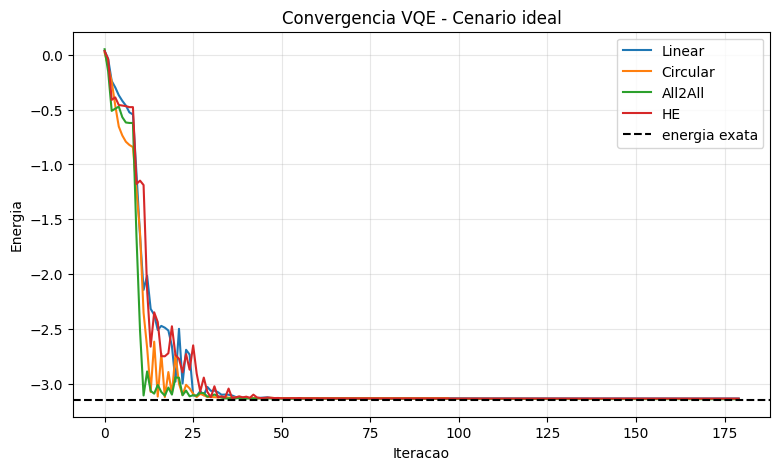

In [141]:
plt.figure(figsize=(9, 5))
for name, res in ideal_results.items():
    plt.plot(res["trace"], label=name)
plt.axhline(exact_energy, linestyle="--", color="black", label="energia exata")
plt.title("Convergencia VQE - Cenario ideal")
plt.xlabel("Iteracao")
plt.ylabel("Energia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 8. Simulação em cenário ruidoso (canal de despolarização)

#### Parâmetro de ruído
Defina `p` conforme orienção do roteiro *hans on*.

# USO DO QISKIT, pois no Kuatomu tivemos problemas (e-mail documentado)

In [142]:
import numpy as np
from itertools import combinations
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE
from qiskit_aer.primitives import EstimatorV2
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [143]:
def get_ansatz_program():
    circuit = QuantumCircuit(4)
    # Criando os parâmetros reutilizáveis no Qiskit
    params = [Parameter(f"p_{i}") for i in range(8)]
    
    for i in range(4):
        circuit.ry(params[i], i)
        circuit.rz(params[i + 4], i)
    return circuit

def build_ansatz_linear():
    circuit = get_ansatz_program()
    circuit.cx(0, 1)
    circuit.cx(1, 2)
    circuit.cx(2, 3)
    return circuit
    
def build_ansatz_circular():
    circuit = get_ansatz_program()
    circuit.cx(0, 1)
    circuit.cx(1, 2)
    circuit.cx(2, 3)
    circuit.cx(3, 0)
    return circuit
    
def build_ansatz_all_to_all():
    circuit = get_ansatz_program()
    all_pairs = list(combinations(range(4), 2))
    for (i, j) in all_pairs:
        circuit.cx(i, j)
    return circuit
        
def build_ansatz_hardware_efficient():
    circuit = get_ansatz_program()
    connectivity = [(0, 1), (2, 3), (0, 2), (1, 3)]
    for (i, j) in connectivity:
        circuit.cx(i, j)
    return circuit

In [144]:
ansatz_specs = {
    "Linear": {"builder": build_ansatz_linear()},
    "Circular": {"builder": build_ansatz_circular()},
    "All2All": {"builder": build_ansatz_all_to_all()},
    "HE": {"builder": build_ansatz_hardware_efficient()}
}

In [145]:
p_depolar = 0.03  # probabilidade de despolarizacao

# implementacao do ruido
noise_model = NoiseModel()
error_1q = depolarizing_error(p_depolar, 1)
error_2q = depolarizing_error(p_depolar, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

qiskit_terms = [(pauli[::-1], coeff) for coeff, pauli in terms_data]

H4_qiskit = SparsePauliOp.from_list(qiskit_terms)

In [146]:
def run_vqe_qiskit(ansatz, observable, maxiter=180, noise=True):
    trace = []
    def callback(eval_count, parameters, mean, metadata):
        trace.append(mean)

    optimizer = COBYLA(maxiter=maxiter, tol=1e-3)
    
    if noise:
        estimator = EstimatorV2(
            options={
                "run_options": {"shots": 1024},
                "backend_options": {"noise_model": noise_model, "seed_simulator": 42}
            }
        )
    else:
        estimator = EstimatorV2(
            options={
                "run_options": {"shots": 1024},
                "backend_options": {"seed_simulator": 42},
            }
        )
    
    vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer, callback=callback, initial_point=[0.1] * 8)
    
    result = vqe.compute_minimum_eigenvalue(operator=observable)
    
    return {
        "energy": float(result.eigenvalue.real),
        "params": result.optimal_point.tolist(),
        "trace": trace,
        "iterations": len(trace),
    }

In [147]:
noisy_results = {}

for name, spec in ansatz_specs.items():
    print(f"Executando ideal: {name}")
    res = run_vqe_qiskit(spec["builder"], H4_qiskit, maxiter=180, noise=True)
    noisy_results[name] = res
    print(f"   Energia final: {res['energy']:.6f} | Iterações: {res['iterations']}")

print("\nConcluído: cenário com ruído.")

Executando ideal: Linear
   Energia final: -2.863063 | Iterações: 180
Executando ideal: Circular
   Energia final: -2.724058 | Iterações: 110
Executando ideal: All2All
   Energia final: -2.752405 | Iterações: 180
Executando ideal: HE
   Energia final: -2.774473 | Iterações: 180

Concluído: cenário com ruído.


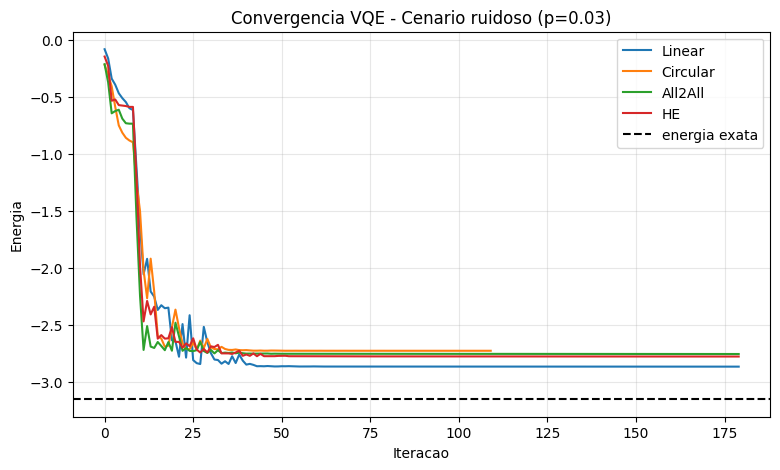

In [148]:
plt.figure(figsize=(9, 5))
for name, res in noisy_results.items():
    plt.plot(res["trace"], label=name)
plt.axhline(exact_energy, linestyle="--", color="black", label="energia exata")
plt.title(f"Convergencia VQE - Cenario ruidoso (p={p_depolar})")
plt.xlabel("Iteracao")
plt.ylabel("Energia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 8.1. Referência de execução em GPU (não obrigatória)

#### Exemplo de adaptação
Abaixo está um bloco de referência (comentado) para utilização de backend ou simulador com aceleração em GPU. Ajuste a configuração conforme o ambiente da instituição.

In [ ]:
# EXEMPLO DE REFERÊNCIA (NÃO EXECUTAR NO GABARITO PADRÃO)
#
# from modulo_backend_gpu import get_gpu_qpu
# gpu_qpu = get_gpu_qpu(device_id=0)
#
# qpu_gpu = ScipyMinimizePlugin(
#     method="COBYLA",
#     tol=1e-3,
#     options={"maxiter": 180},
# ) | gpu_qpu
#
# job_gpu = ansatz1.to_job(observable=H4)
# result_gpu = qpu_gpu.submit(job_gpu)
# print("Energia VQE (GPU):", result_gpu.value)

### 9. Análise comparativa e recomendação

#### Tabela-sintese (8 cenarios)
A tabela a seguir reúne os resultados obtidos para 4 ansatze em 2 condições de execução (ideal e ruidosa).

In [149]:
rows = []
for name in ansatz_specs.keys():
    e_ideal = ideal_results[name]["energy"]
    e_noisy = noisy_results[name]["energy"]

    rows.append({
        "ansatz": name,
        "cenario": "ideal",
        "energia_final": e_ideal,
        "energia_final_ideal": e_ideal,
        "iteracoes": ideal_results[name]["iterations"],
        "erro_abs_vs_exato": abs(e_ideal - exact_energy),
        "delta_vs_ideal": 0.0,
    })

    rows.append({
        "ansatz": name,
        "cenario": "ruidoso",
        "energia_final": e_noisy,
        "energia_final_ideal": e_ideal,
        "iteracoes": noisy_results[name]["iterations"],
        "erro_abs_vs_exato": abs(e_noisy - exact_energy),
        "delta_vs_ideal": abs(e_noisy - e_ideal),
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(["ansatz", "cenario"]).reset_index(drop=True)
df_results

,ansatz,cenario,energia_final,energia_final_ideal,iteracoes,erro_abs_vs_exato,delta_vs_ideal
0,All2All,ideal,-3.139688,-3.139688,180,0.008924,0.000000
1,All2All,ruidoso,-2.752405,-3.139688,180,0.396207,0.387283
2,Circular,ideal,-3.130000,-3.130000,98,0.018611,0.000000
3,Circular,ruidoso,-2.724058,-3.130000,110,0.424553,0.405942
4,HE,ideal,-3.133737,-3.133737,180,0.014874,0.000000
5,HE,ruidoso,-2.774473,-3.133737,180,0.374138,0.359264
6,Linear,ideal,-3.133036,-3.133036,180,0.015575,0.000000
7,Linear,ruidoso,-2.863063,-3.133036,180,0.285548,0.269972


In [151]:
# Ranking simples de robustez no cenario ruidoso
df_noisy = df_results[df_results["cenario"] == "ruidoso"].copy()
df_noisy = df_noisy.sort_values(["erro_abs_vs_exato", "delta_vs_ideal", "iteracoes"])

best_ansatz = df_noisy.iloc[0]["ansatz"]

print("Energia exata de referencia:", round(exact_energy, 6))
print("Ansatz recomendado (criterio: menor erro + maior robustez):", best_ansatz)
print("\nResumo ruidoso ordenado:")
display(df_noisy)

Energia exata de referencia: -3.148611
Ansatz recomendado (criterio: menor erro + maior robustez): Linear

Resumo ruidoso ordenado:


,ansatz,cenario,energia_final,energia_final_ideal,iteracoes,erro_abs_vs_exato,delta_vs_ideal
7,Linear,ruidoso,-2.863063,-3.133036,180,0.285548,0.269972
5,HE,ruidoso,-2.774473,-3.133737,180,0.374138,0.359264
1,All2All,ruidoso,-2.752405,-3.139688,180,0.396207,0.387283
3,Circular,ruidoso,-2.724058,-3.130000,110,0.424553,0.405942


### 10. Conclusão

Elabore uma conclusão a partir dos resultados obtidos, considerando os pontos indicados a seguir.

#### Guia para discussão

### 1. Qual topologia teve melhor compromisso entre precisão e robustez ao ruído?
O ansatz linear teve o melhor compromisso entre a precisão e robustez ao ruído. Observa-se que em um cenário ideal, todos os ansatze têm erros muito similares, tais como o menor erro para o All2All (0.008924) e maior erro para o Circular (0.018611). Porém, no cenário com ruído, apresenta uma degradação de 0.269972, ou seja, ~25% menor que o HE segundo de menor degradação. Já o Circular tem pior degradação com 0.405942, seguido do All2All com 0.387283. 
Conclui-se com base nesse experimento que o ansatz Linear protege mais contra acúmulo de ruídos, mesmo tendo uma conectividade reduzida e com pouca expressividade.

### 2. Como a profundidade (quantidade de CNOTs) afetou a degradação por ruído?
A degradação está diretamente ligada com as portas CNOTs. Os ansatze All2All e Circular têm mais portas CNOTs e, portanto, possuem conectividade mais densa. Por isso, amplificam-se erros de depolarização a cada operação, com erros absolutos de 0.396207 e 0.424553, respectivamente. O ansatz Linear minimiza a profundidade do circuito dado que a conectividade ocorre apenas entre vizinhos resultando em menos erros acumulados. O Circular convergiu logo com 110 iterações (os demais tiveram iteração limite de 180), possivelmente preso a um mínimo local em função do ruído. Por fim, o HE tem robustez moderada, apenas sendo ultrapassado pelo Linear, mostrando que a sua projeção é justamente para reduzir profundidade.

### 3. Qual ansatz você recomendaria para dispositivo NISQ com topologia de grade?
Com certeza recomendaríamos o ansatz Linear. Como exemplo, ao considerarmos dispositivos NISQ como os da IBM com topologia em grade, esta já possui conectividade limitada aos seus qubits vizinhos mais próximos. Portanto, o Linear mapeia diretamente a arquitetura desse hardware sem precisar portas extras como as SWAPs. Isso é importante, pois elimina uma camada de profundidade no circuito que os ansatze All2All e HE exigiriam.